<a href="https://colab.research.google.com/github/IshaVishwakarma/ETA-Prediction/blob/main/ETA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("microize/newyork-yellow-taxi-trip-data-2020-2019")

print("Path to dataset files:", path)

100%|██████████| 1.81G/1.81G [00:21<00:00, 89.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/microize/newyork-yellow-taxi-trip-data-2020-2019/versions/25


In [2]:
import os

print(os.listdir(path))

['yellow_tripdata_2019-11.csv', 'yellow_tripdata_2020-04.csv', 'yellow_tripdata_2020-01.csv', 'yellow_tripdata_2020-03.csv', 'yellow_tripdata_2020-06.csv', 'yellow_tripdata_2019-06.csv', 'yellow_tripdata_2019-04.csv', 'yellow_tripdata_2019-01.csv', 'yellow_tripdata_2019-03.csv', 'yellow_tripdata_2019-12.csv', 'taxi+_zone_lookup.csv', 'yellow_tripdata_2019-05.csv', 'yellow_tripdata_2019-10.csv', 'taxi_zones', 'yellow_tripdata_2019-07.csv', 'yellow_tripdata_2019-08.csv', 'yellow_tripdata_2020-02.csv', 'yellow_tripdata_2019-09.csv', 'yellow_tripdata_2020-05.csv', 'yellow_tripdata_2019-02.csv']


In [3]:
file_path = path + "/yellow_tripdata_2019-01.csv"  # change name if different

import pandas as pd

df = pd.read_csv(file_path)

print(df.head())

   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         1  2019-01-01 00:46:40   2019-01-01 00:53:20                1   
1         1  2019-01-01 00:59:47   2019-01-01 01:18:59                1   
2         2  2018-12-21 13:48:30   2018-12-21 13:52:40                3   
3         2  2018-11-28 15:52:25   2018-11-28 15:55:45                5   
4         2  2018-11-28 15:56:57   2018-11-28 15:58:33                5   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0            1.5           1                  N           151           239   
1            2.6           1                  N           239           246   
2            0.0           1                  N           236           236   
3            0.0           1                  N           193           193   
4            0.0           2                  N           193           193   

   payment_type  fare_amount  extra  mta_tax  tip_amount  tolls_amount  \


In [4]:
print(df.columns)

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge'],
      dtype='object')


In [5]:
import pandas as pd

# convert to datetime
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

# create target variable
df["trip_duration"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds()

# check result
print(df[["tpep_pickup_datetime", "tpep_dropoff_datetime", "trip_duration"]].head())

  tpep_pickup_datetime tpep_dropoff_datetime  trip_duration
0  2019-01-01 00:46:40   2019-01-01 00:53:20          400.0
1  2019-01-01 00:59:47   2019-01-01 01:18:59         1152.0
2  2018-12-21 13:48:30   2018-12-21 13:52:40          250.0
3  2018-11-28 15:52:25   2018-11-28 15:55:45          200.0
4  2018-11-28 15:56:57   2018-11-28 15:58:33           96.0


In [6]:
# remove invalid trips
df = df[df["trip_duration"] > 60]     # at least 1 minute
df = df[df["trip_duration"] < 7200]   # max 2 hours

In [7]:
print(df["trip_duration"].describe())

count    7.571387e+06
mean     7.763059e+02
std      5.940206e+02
min      6.100000e+01
25%      3.710000e+02
50%      6.130000e+02
75%      9.940000e+02
max      7.198000e+03
Name: trip_duration, dtype: float64


In [8]:
df["hour"] = df["tpep_pickup_datetime"].dt.hour
df["day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek

In [9]:
df = df.drop(columns=[
    "fare_amount",
    "total_amount",
    "tip_amount"
])

In [10]:
X = df[["trip_distance", "hour", "day_of_week"]]
y = df["trip_duration"]

In [11]:
print(X.head())

   trip_distance  hour  day_of_week
0            1.5     0            1
1            2.6     0            1
2            0.0    13            4
3            0.0    15            2
4            0.0    15            2


In [12]:
from sklearn.model_selection import train_test_split

X = df[["trip_distance", "hour", "day_of_week"]]
y = df["trip_duration"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
df_sample = df.sample(n=100000, random_state=42)

X = df_sample[["trip_distance", "hour", "day_of_week"]]
y = df_sample["trip_duration"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=20,   # reduce trees
    max_depth=10       # limit depth
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=20)

In [17]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=50,
    max_depth=6,
    learning_rate=0.1
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, num_parallel_tree=None, ...)

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(model, X_test, y_test):
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    return mae, rmse

rf_mae, rf_rmse = evaluate(rf, X_test, y_test)
xgb_mae, xgb_rmse = evaluate(xgb, X_test, y_test)

print("Random Forest → MAE:", rf_mae, "RMSE:", rf_rmse)
print("XGBoost → MAE:", xgb_mae, "RMSE:", xgb_rmse)

Random Forest → MAE: 183.36619423103647 RMSE: 282.9164445960596
XGBoost → MAE: 181.18775915603638 RMSE: 278.35771196567765


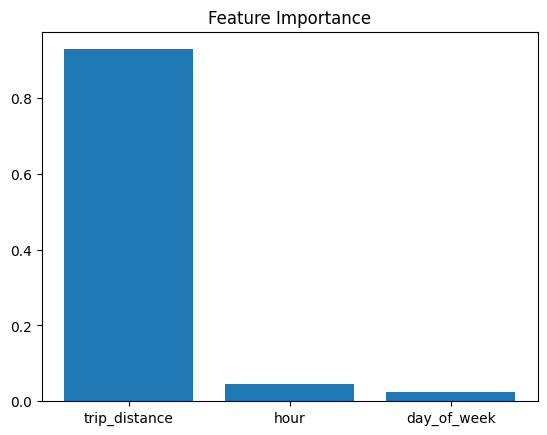

In [19]:
import matplotlib.pyplot as plt

importance = xgb.feature_importances_
features = ["trip_distance", "hour", "day_of_week"]

plt.bar(features, importance)
plt.title("Feature Importance")
plt.show()

In [27]:
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)
df["is_rush_hour"] = df["hour"].isin([8,9,17,18,19]).astype(int)

In [36]:
# Step 1: Recreate target (just to be safe)
y = df["trip_duration"]

# Step 2: Recreate features AFTER all changes
X = df[[
    "trip_distance",
    "hour",
    "day_of_week",
    "is_weekend",
    "is_rush_hour"
]]

In [31]:
print(len(X), len(y))

7571387 7571387


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=50,
    max_depth=6,
    learning_rate=0.1
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, num_parallel_tree=None, ...)

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(model, X_test, y_test):
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    return mae, rmse


xgb_mae, xgb_rmse = evaluate(xgb, X_test, y_test)


print("XGBoost → MAE:", xgb_mae, "RMSE:", xgb_rmse)

XGBoost → MAE: 181.29764267156025 RMSE: 276.33548718225563


In [37]:
pickup_counts = df.groupby("PULocationID")["trip_duration"].count()

df["pickup_traffic"] = df["PULocationID"].map(pickup_counts)

In [38]:
drop_counts = df.groupby("DOLocationID")["trip_duration"].count()

df["drop_traffic"] = df["DOLocationID"].map(drop_counts)

In [39]:
X = df[[
    "trip_distance",
    "hour",
    "day_of_week",
    "is_weekend",
    "is_rush_hour",
    "pickup_traffic",
    "drop_traffic"
]]

In [40]:
df = df.dropna()

In [41]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=50,
    max_depth=6,
    learning_rate=0.1
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, num_parallel_tree=None, ...)

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(model, X_test, y_test):
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    return mae, rmse


xgb_mae, xgb_rmse = evaluate(xgb, X_test, y_test)


print("XGBoost → MAE:", xgb_mae, "RMSE:", xgb_rmse)

XGBoost → MAE: 181.29764267156025 RMSE: 276.33548718225563


In [43]:
pickup_hour_traffic = df.groupby(["PULocationID", "hour"])["trip_duration"].count()

df["pickup_hour_traffic"] = df.set_index(["PULocationID", "hour"]).index.map(pickup_hour_traffic)

/tmp/ipykernel_1095/3840332116.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["pickup_hour_traffic"] = df.set_index(["PULocationID", "hour"]).index.map(pickup_hour_traffic)


In [44]:
df = df.copy()

In [45]:
pickup_hour_traffic = df.groupby(["PULocationID", "hour"])["trip_duration"].count()

df["pickup_hour_traffic"] = df.set_index(["PULocationID", "hour"]).index.map(pickup_hour_traffic)

In [46]:
X = df[[
    "trip_distance",
    "hour",
    "day_of_week",
    "is_weekend",
    "is_rush_hour",
    "pickup_hour_traffic"
]]

In [47]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=50,
    max_depth=6,
    learning_rate=0.1
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, num_parallel_tree=None, ...)

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(model, X_test, y_test):
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    return mae, rmse


xgb_mae, xgb_rmse = evaluate(xgb, X_test, y_test)


print("XGBoost → MAE:", xgb_mae, "RMSE:", xgb_rmse)

XGBoost → MAE: 181.29764267156025 RMSE: 276.33548718225563


In [49]:
pip install fastapi uvicorn joblib

In [53]:
import os

os.makedirs("eta-prediction-system/src", exist_ok=True)
os.makedirs("eta-prediction-system/models", exist_ok=True)

In [54]:
import joblib

joblib.dump(xgb, "eta-prediction-system/models/eta_model.pkl")

['eta-prediction-system/models/eta_model.pkl']

In [55]:
code = """
# paste your main.py code here
"""

with open("eta-prediction-system/main.py", "w") as f:
    f.write(code)

In [56]:
with open("eta-prediction-system/requirements.txt", "w") as f:
    f.write("pandas\nnumpy\nscikit-learn\nxgboost\njoblib")

In [57]:
readme = """# ETA Prediction System

Built an ML model to predict taxi trip duration using NYC Taxi dataset.

- Model: XGBoost
- RMSE: ~276 seconds
"""

with open("eta-prediction-system/README.md", "w") as f:
    f.write(readme)

In [58]:
!zip -r eta-prediction-system.zip eta-prediction-system

  adding: eta-prediction-system/ (stored 0%)
  adding: eta-prediction-system/requirements.txt (stored 0%)
  adding: eta-prediction-system/models/ (stored 0%)
  adding: eta-prediction-system/models/eta_model.pkl (deflated 72%)
  adding: eta-prediction-system/main.py (stored 0%)
  adding: eta-prediction-system/src/ (stored 0%)
  adding: eta-prediction-system/README.md (deflated 13%)


In [59]:
from google.colab import files
files.download("eta-prediction-system.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>